# Basic Chatbot with LangGraph (GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

/Users/tannutiwari/Downloads/Projects/AgenticLangGraph/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model


#llm initialization using ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1106118d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x110772090>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
#llm initialization using init_chat_model
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x110784cd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x110785890>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder=StateGraph(State)


graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

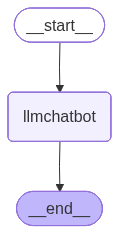

In [8]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response=graph.invoke({"messages":"Hi"})

In [10]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [11]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings in the same way that humans do, but I'm here and ready to help with any questions or tasks you may have. How can I assist you today?


# Chatbot With Tool

In [12]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
   'title': 'What is LangGraph? - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for bui

In [13]:
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [14]:
tools=[tool,multiply]

In [15]:
llm_with_tool=llm.bind_tools(tools)

In [16]:
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x110784cd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x110785890>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, acc

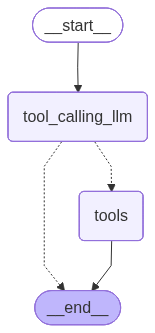

In [17]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [19]:
response['messages'][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/387363/more-americans-are-ditching-dr-google-for-ai.html", "title": "More Americans Are Turning to AI, Ditching Dr. Google - Newser", "score": 0.73914057, "published_date": "Sat, 18 Apr 2026 18:30:00 GMT", "content": "Image 8: Newser - Current News - Breaking Stories. Image 9: Newser - Current News - Breaking Stories. *   Image 20 Accountants Would Like AI to Take This Job for Good. *   Image 23 AI-Assisted Hackers Blamed for Massive Security Breach. *   Image 25 Berklee Students Revolt Over AI Songwriting Class. *   Image 26 Allbirds\' Stock Jumps 467% on Plan to Shift From Shoes to AI. *   Image 30 Op-Ed: For AI Safety, It\'s Time to Align With China. *   Image 38 Religion Has Gone AI. Image 45: More Americans Are Ditching Dr. Google for AI. The poll, conducted in late 2025 and backed up by at least three other recent surveys with similar findings,

In [20]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wjb4az0ez)
 Call ID: wjb4az0ez
  Args:
    query: recent ai news
    start_date: None
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/387363/more-americans-are-ditching-dr-google-for-ai.html", "title": "More Americans Are Turning to AI, Ditching Dr. Google - Newser", "score": 0.73914057, "published_date": "Sat, 18 Apr 2026 18:30:00 GMT", "content": "Image 8: Newser - Current News - Breaking Stories. Image 9: Newser - Current News - Breaking Stories. *   Image 20 Accountants Would Like AI to Take This Job for Good. *   Image 23 AI-Assisted Hackers

In [21]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (7vm8jps8v)
 Call ID: 7vm8jps8v
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [22]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (4vx6fgzjs)
 Call ID: 4vx6fgzjs
  Args:
    query: recent AI news
    topic: news
  multiply (2fbkyaxe2)
 Call ID: 2fbkyaxe2
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/tylerroush/2026/05/04/white-house-may-review-new-ai-models-before-public-release-report-says/", "title": "White House May Review New AI Models Before Public Release, Report Says - Forbes", "score": 0.96267307, "published_date": "Mon, 04 May 2026 19:44:09 GMT", "content": "# Trump May Review AI Models Before Release, Report Says. *   The Enterprise AI Shortcut: Wh

# ReAct Agent Architecture

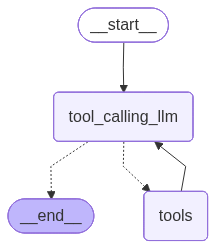

In [23]:
## Stategraph
from langgraph.graph import StateGraph,START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ehyn4m432)
 Call ID: ehyn4m432
  Args:
    query: recent ai news
    time_range: week
    topic: news
  multiply (hwqfm646x)
 Call ID: hwqfm646x
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tipranks.com/news/private-companies/datarobot-highlights-ai-agent-infrastructure-governance-and-evolving-workforce-roles", "title": "DataRobot Highlights AI Agent Infrastructure, Governance, and Evolving Workforce Roles - TipRanks", "score": 0.69746524, "published_date": "Sun, 03 May 2026 18:02:21 GMT", "content": "According to a recent LinkedIn post from Dat

# Adding Memory In Agentic Graph

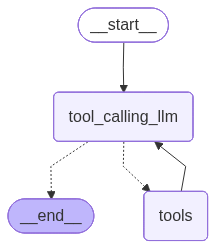

In [28]:
## Stategraph
from langgraph.graph import StateGraph,START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Tanu"},config=config)

response['messages'][-1].content

'Nice to meet you Tanu. Is there anything I can help you with?'

In [29]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

I don't have any information about your name. I'm a large language model, I don't have the ability to know or store personal information about individual users. If you'd like to tell me your name, I'd be happy to chat with you about it!


# Streaming

In [30]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [31]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

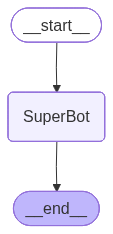

In [32]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [33]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Tanu And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Tanu And I like cricket', additional_kwargs={}, response_metadata={}, id='58771334-7c52-44f4-a8fe-f4bd0f3e8c94'),
  AIMessage(content="Nice to meet you, Tanu! It's great to hear that you like cricket. Are you a fan of any specific team or player? Do you enjoy watching international cricket or domestic leagues like the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 46, 'total_tokens': 94, 'completion_time': 0.077863416, 'completion_tokens_details': None, 'prompt_time': 0.005903902, 'prompt_tokens_details': None, 'queue_time': 0.051755318, 'total_time': 0.083767318}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d90-6573-7de2-8a4a-05b46fc6e9f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [34]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Tanu And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Tanu, nice to meet you. Cricket is a fantastic sport, and it's great to hear that you're a fan. Which aspect of cricket do you enjoy the most? Is it the thrill of watching international matches, the excitement of local league matches, or perhaps the strategy involved in playing the game?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 46, 'total_tokens': 110, 'completion_time': 0.10264512, 'completion_tokens_details': None, 'prompt_time': 0.002745735, 'prompt_tokens_details': None, 'queue_time': 0.050911534, 'total_time': 0.105390855}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d90-6c59-7a12-9ecc-8f034311d8fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 64, 'total_tokens': 110})]}}


In [35]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Tanu And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Tanu And I like cricket', additional_kwargs={}, response_metadata={}, id='f4d13ec2-5d10-42f2-b384-a65fa96750a8'), AIMessage(content="Hello Tanu, nice to meet you. Cricket is a fantastic sport, and it's great to hear that you're a fan. Which aspect of cricket do you enjoy the most? Is it the thrill of watching international matches, the excitement of local league matches, or perhaps the strategy involved in playing the game?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 46, 'total_tokens': 110, 'completion_time': 0.10264512, 'completion_tokens_details': None, 'prompt_time': 0.002745735, 'prompt_tokens_details': None, 'queue_time': 0.050911534, 'total_time': 0.105390855}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d90-6c59-7a12-9ecc-8f03

In [36]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Tanu And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Tanu. Cricket is a fantastic sport, and I'm sure you have a great passion for it. Which team or player do you support? Are you a fan of the Indian cricket team, or do you have a favorite team from another country?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 46, 'total_tokens': 102, 'completion_time': 0.074799258, 'completion_tokens_details': None, 'prompt_time': 0.002153087, 'prompt_tokens_details': None, 'queue_time': 0.051692612, 'total_time': 0.076952345}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d90-772a-71f2-bcc7-68816850787a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 56, 'total_tokens': 102})]}}


In [37]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Tanu And I like cricket', additional_kwargs={}, response_metadata={}, id='5c930511-9e54-421b-b82a-9b84c6a6dd7a'), AIMessage(content="Nice to meet you, Tanu. Cricket is a fantastic sport, and I'm sure you have a great passion for it. Which team or player do you support? Are you a fan of the Indian cricket team, or do you have a favorite team from another country?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 46, 'total_tokens': 102, 'completion_time': 0.074799258, 'completion_tokens_details': None, 'prompt_time': 0.002153087, 'prompt_tokens_details': None, 'queue_time': 0.051692612, 'total_time': 0.076952345}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d90-772a-71f2-bcc7-68816850787a-0', tool_calls=[], invalid_tool_calls=[], usage_metad